In [2]:
# Домашнее задание 4
# Загрузить данные, разделить их на обучающую и тестовую выборки
import numpy as np
import mathplotlib  as plt
from io import StringIO
import pandas as pd
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import title
from numpy import dtype
from pandas.core.interchange import column
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("data\\heart.csv")
print('ВЫВОД МАССИВА')
df.head(10)
#несбалансированность
X = df.drop(["target"], axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
print(f'Оценка выборки на сбалансированность \n {y_train.value_counts()}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Размер обучающей выборки, признаки: {X_train.shape}')
print(f'Размер тестовой выборки, признаки: {X_test.shape}')
print(f'Размер обучающей выборки, целевая переменная {y_train.shape}')
print(f'Размер тестовой выборки, целевая переменная {y_test.shape}')


ВЫВОД МАССИВА
Оценка выборки на сбалансированность 
 target
1    133
0    109
Name: count, dtype: int64
Размер обучающей выборки, признаки: (242, 13)
Размер тестовой выборки, признаки: (61, 13)
Размер обучающей выборки, целевая переменная (242,)
Размер тестовой выборки, целевая переменная (61,)


In [28]:
''' 2. Обучить модели наивного байесовского классификатора, логистической регрессии и k-ближайших соседей (выявить k с наилучшим результатом, например, путем перебора результатов, получаемых для классификаторов с разными значениями k)
'''
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# Инициализация модели Наивного Байеса
ht_model = GaussianNB()

# Обучение модели
ht_model.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_ht = ht_model.predict(X_test)

# Оценка точности модели
accuracy_ht = accuracy_score(y_test, y_pred_ht)
print(f"Точность Наивного Байеса: {accuracy_ht:.4f}")
#логистическая регрессия


''' в параметре Solver  применяем 'liblinear' он оптимизирует веса поочередно (метод координатного спуска), что делает его вычислительно # эффективным для простых задач. '''
# В переменную записываем «пустую» заготовку модели (архитектуру).
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=77)

# Обучение модели
log_reg_model.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_lr = log_reg_model.predict(X_test)

# Оценка точности модели
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Точность Логистической регрессии:\n {accuracy_lr:.4f}")
# отчет по классификации
print(f" отчет по классификации \n {classification_report(y_test, y_pred_lr)}")



Точность Наивного Байеса: 0.8197
Точность Логистической регрессии:
 0.8033
 отчет по классификации 
               precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



In [29]:
#k nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
k_values = range(1, 31) # Пробуем K от 1 до 30
accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred_knn = knn_model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_knn))

# Находим K с большей точностью
best_k = k_values[np.argmax(accuracies)]
best_accuracy_knn = np.max(accuracies)

print(f"Лучшее значение K : {best_k}")
print(f"Точность модели с лучшим K ({best_k}): {best_accuracy_knn:.4f}")

# Обучим и оценим финальную модель с найденным лучшим K
final_knn_model = KNeighborsClassifier(n_neighbors=best_k)
final_knn_model.fit(X_train, y_train)
y_pred_final_knn = final_knn_model.predict(X_test)
accuracy_final_knn = accuracy_score(y_test, y_pred_final_knn)

# Это должно быть то же самое, что и best_accuracy_knn, но это подтверждает финальную модель
print(f"Финальная точность KNN модели с K={best_k}: {accuracy_final_knn:.4f}")


Лучшее значение K : 16
Точность модели с лучшим K (16): 0.6721
Финальная точность KNN модели с K=16: 0.6721



--- Наивный Байес ---
Accuracy: 0.8197
Precision: 0.7895
Recall: 0.9091
F1-score: 0.8451


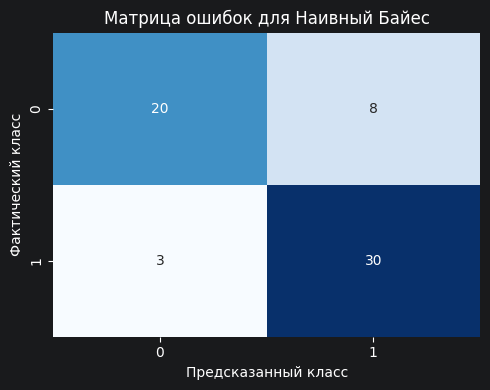

In [32]:
#Построить матрицу ошибок, оценить модель с помощью accuracy, precision, recall и F1-score
import matplotlib.pyplot as plt
import seaborn as sns
# Импортируем метрики из scikit-learn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

print(f"Оценка моделей с использованием матрицы ошибок и метрик:\n")

def evaluate_model(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    plt.figure(figsize=(5, 4))
    # xticklabels и yticklabels лучше делать короткими, так как у вас уже есть plt.xlabel и plt.ylabel
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["0", "1"],
        yticklabels=["0", "1"],
    )
    plt.title(f"Матрица ошибок для {model_name}")
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Фактический класс")
    plt.tight_layout()  # Защищает текст от обрезания по краям графика
    plt.show()
evaluate_model("Наивный Байес", y_test, y_pred_ht)


Первые 5 предсказанных вероятностей положительного класса для каждой модели:

Значения наивного байеса: [2.06868888e-03 1.12848161e-01 2.14486658e-04 3.68034295e-01
 9.18430723e-01]
Значения наивного логистическая регрессия: [0.08341032 0.21778863 0.00632296 0.7237826  0.69800682]
Значения наивного к ближайщих сосседей: [0.0625 0.5625 0.25   0.625  0.8125]

Площадь под ROC-кривой (AUC) для модели: 0.8755


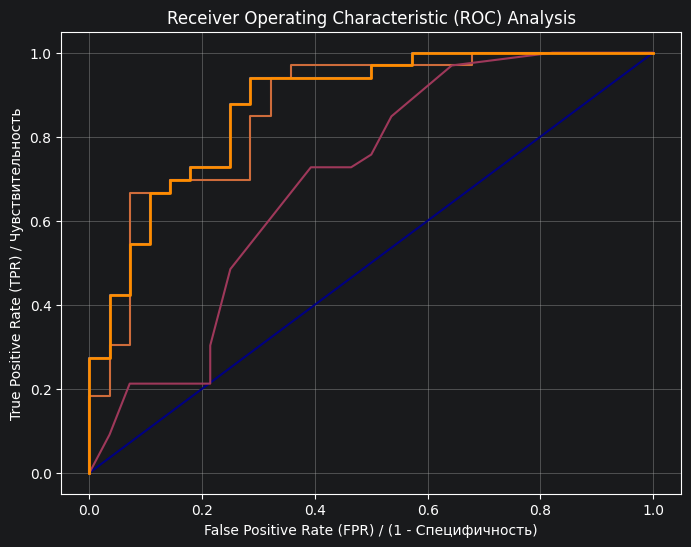


AUC для Наивного Байеса: 0.8755
AUC для Логистической регрессии: 0.8615
AUC для KNN (k=16): 0.6970


In [43]:
#Провести ROC-анализ обученных классификаторов
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# получение вероятностей принадлежности к положительному классу (1)
y_probs = ht_model.predict_proba(X_test)[:, 1]
y_probs_lg = log_reg_model.predict_proba(X_test)[:, 1]
y_probs_km = final_knn_model.predict_proba(X_test)[:, 1]

print("Первые 5 предсказанных вероятностей положительного класса для каждой модели:\n")
print(f"Значения наивного байеса: {y_probs[:5]}")
print(f"Значения логистическая регрессия: {y_probs_lg[:5]}")
print(f"Значения К ближайших сосседей: {y_probs_km[:5]}")
# расчет FPR, TPR и порогов
fpr, tpr, thresholds = roc_curve(y_test,
y_probs)
# расчет AUC
roc_auc = auc(fpr, tpr)
print(f"\nПлощадь под ROC-кривой (AUC) для модели: {roc_auc:.4f}")
def plot_roc_curve(model, X_test, y_test, model_name, ax):
    # Получаем вероятности предсказания для положительного класса
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        # Если модель не поддерживает predict_proba (например, некоторые SVMs)
        # мы можем использовать decision_function или просто predict, но для ROC лучше вероятности
        y_probs = model.decision_function(X_test)

    # Вычисляем FPR, TPR и пороги
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    # Вычисляем AUC
    roc_auc = auc(fpr, tpr)

    # Строим ROC-кривую
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

    return roc_auc
#Распаковываем кортеж в две переменные fig и ax
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], color='navy', label='Случайное угадывание (AUC = 0.50)') # Диагональная линия
# Для Наивного Байеса
roc_auc_nb = plot_roc_curve(ht_model, X_test, y_test, "Наивный Байес", ax)

# Для Логистической Регрессии
roc_auc_lr = plot_roc_curve(log_reg_model, X_test, y_test, "Логистическая регрессия", ax)

# Для KNN
roc_auc_knn = plot_roc_curve(final_knn_model, X_test, y_test, f"KNN (k={best_k})", ax)


# построение ROC-кривой
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.4f})')

# построение линии случайного классификатора (диагональ)
#plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор (AUC = 0.5)')


# настройка осей и заголовка
plt.xlabel('False Positive Rate (FPR) / (1 - Специфичность)')
plt.ylabel('True Positive Rate (TPR) / Чувствительность')
plt.title('Receiver Operating Characteristic (ROC) Analysis')
plt.grid(True)
plt.show()
print(f"\nAUC для Наивного Байеса: {roc_auc_nb:.4f}")
print(f"AUC для Логистической регрессии: {roc_auc_lr:.4f}")
print(f"AUC для KNN (k={best_k}): {roc_auc_knn:.4f}")